In [2]:
import tensorflow as tf

print(tf.__version__)

2.9.1


In [52]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Input
from tensorflow.keras.activations import relu, softmax
from tensorflow.keras import Sequential

In [28]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import json

In [9]:
a = np.array([1, 2, 3])
print(a)

[1 2 3]


In [27]:
dataPath = "C:/Users/Wjunxion/Documents/datasets/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5"
with h5py.File(dataPath, 'r') as f:
    # 1. Check what datasets exist inside the file
    print("Keys available:", list(f.keys()))
    
    # 2. Access the target dataset by its key name
    X = f['X'][:]
    Y = f['Y'][:]
    Z = f['Z'][:]
    
print(X.shape)                         
print(Y.shape)                         
print(Z.shape)                         

Keys available: ['X', 'Y', 'Z']
(2555904, 1024, 2)
(2555904, 24)
(2555904, 1)


In [41]:
fixed_classes = json.load(open("../data_labels/classes-fixed.json", 'r'))
print(fixed_classes)

['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']


In [ ]:
# source:
# https://www.kaggle.com/code/suyashkumarbhagat/radio-ml-2018-data-visualisation

# Function to find the indices of a specific modulation type
def find_modulation_indices(modulation_name, classes_fixed):
    modulation_index = classes_fixed.index(modulation_name)
    indices = [i for i, label in enumerate(Y) if np.argmax(label) == modulation_index]
    return indices

def clean_classes(file_path):
    with open(file_path) as f:
        lines = f.readlines()
    classes_fixed = []
    for line in lines:
        if "|" in line and not line.strip().startswith("#"):
            parts = line.split("|")
            if len(parts) == 4:
                fixed_class = parts[3].strip().strip("'")
                if fixed_class and fixed_class not in ["Fixed"]:
                    classes_fixed.append(fixed_class)
    return classes_fixed

def find_modulation_snr_indices(modulation_name, snr_level, classes_fixed, Y, Z):
    modulation_index = classes_fixed.index(modulation_name)
    indices = [i for i, (label, snr) in enumerate(zip(Y, Z)) if np.argmax(label) == modulation_index and snr == snr_level]
    return indices

def plot_signals_by_modulation_snr(modulation_name, snr_level, num_samples):
    indices = find_modulation_snr_indices(modulation_name, snr_level, fixed_classes, Y, Z)
    if len(indices) < num_samples:
        print(f"Not enough samples for {modulation_name} with SNR {snr_level} dB. Found only {len(indices)} samples.")
        return

    samples = np.random.choice(indices, num_samples, replace=False)

    for sample in samples:
        plt.figure(figsize=(30, 3))

        I_phase = X[sample, :, 0]
        Q_phase = X[sample, :, 1]
        magnitude = np.sqrt((I_phase**2) + (Q_phase**2))

        plt.subplot(1, 3, 1)
        plt.plot(I_phase)
        plt.title(f'{modulation_name} - In-phase (I) (SNR: {snr_level} dB)')

        plt.subplot(1, 3, 2)
        plt.plot(Q_phase)
        plt.title(f'{modulation_name} - Quadrature-phase (Q) (SNR: {snr_level} dB)')

        plt.subplot(1, 3, 3)
        plt.plot(magnitude)
        plt.title(f'{modulation_name} - Magnitude (SNR: {snr_level} dB)')

        plt.tight_layout()
        plt.show()

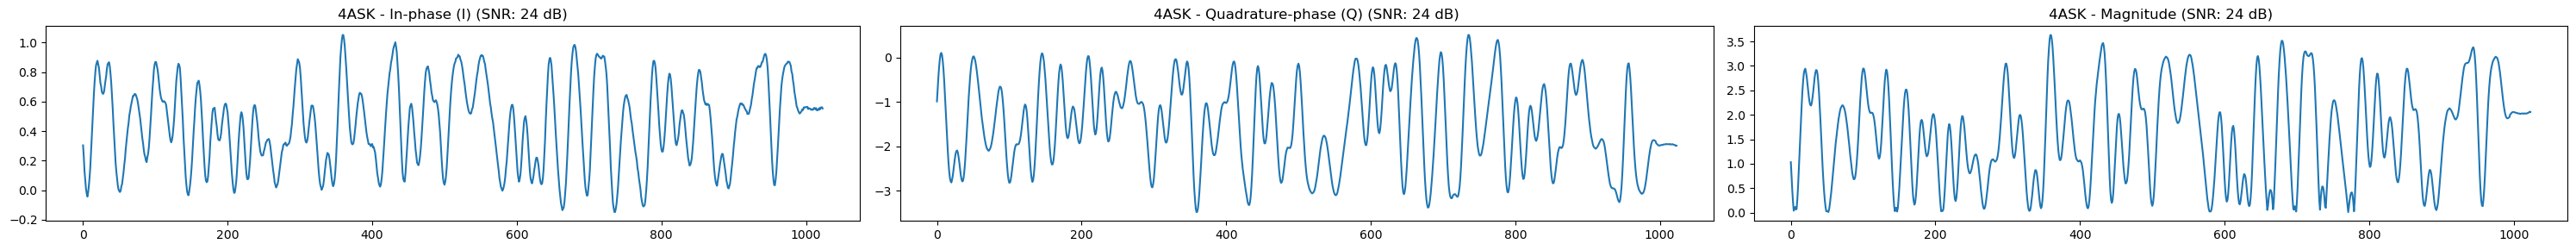

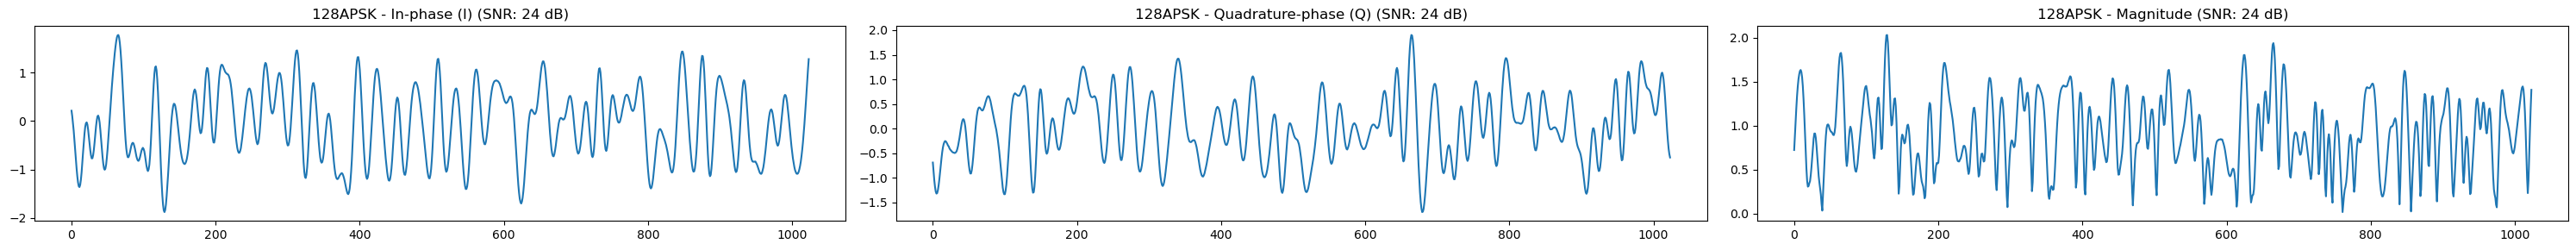

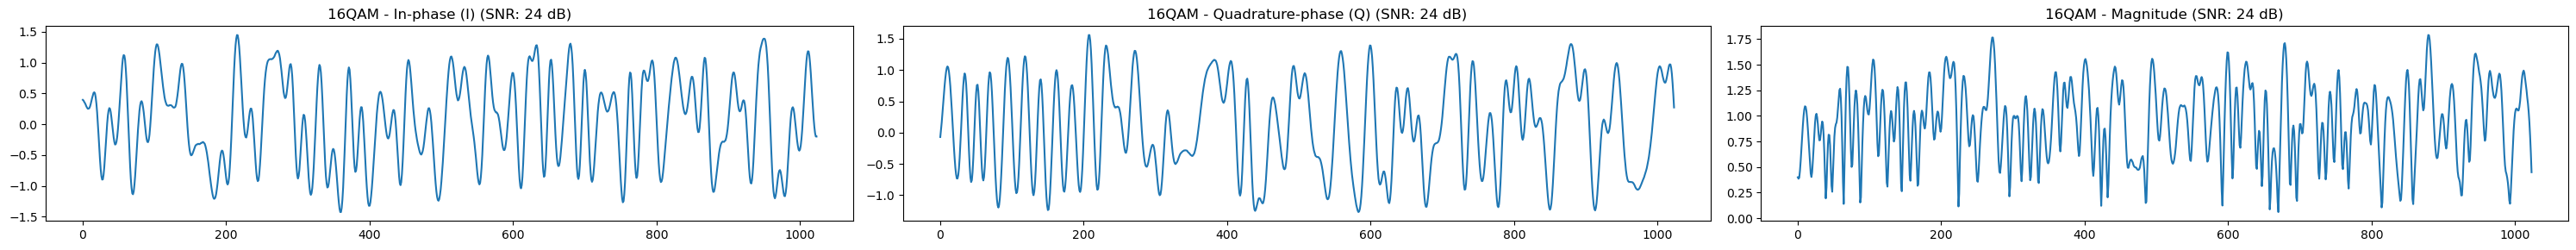

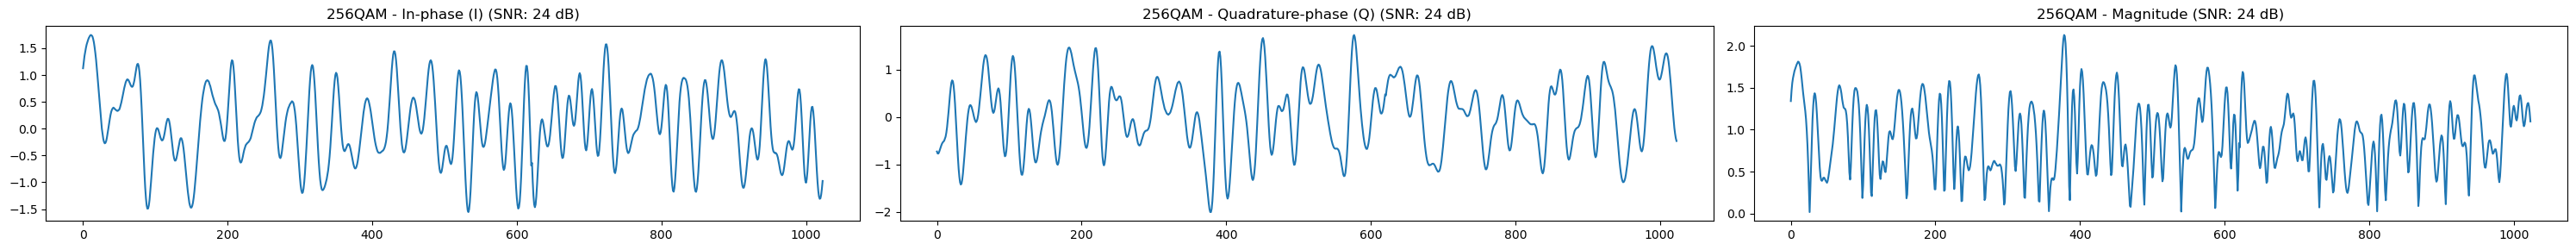

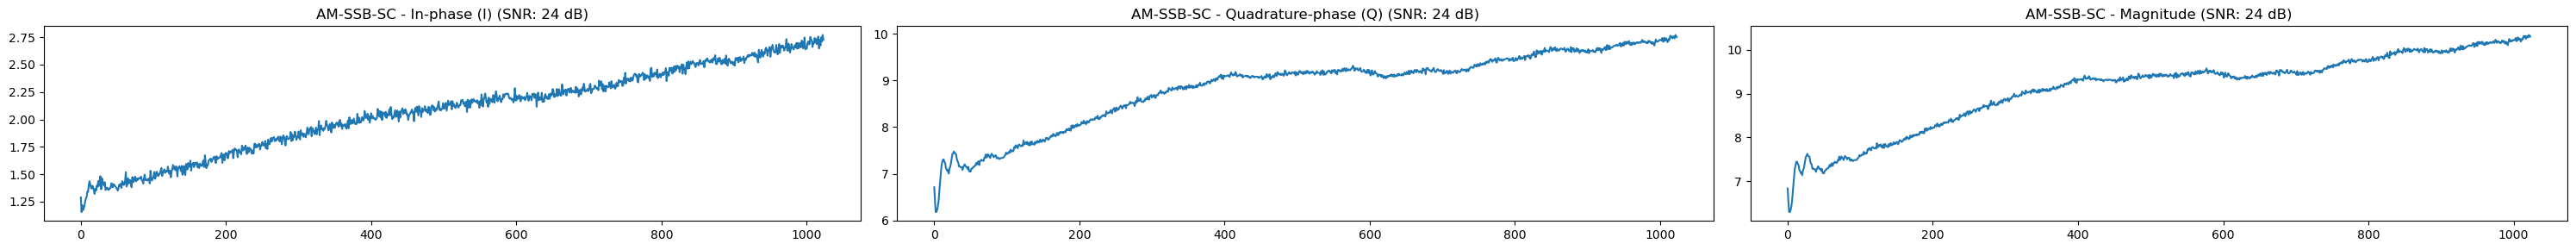

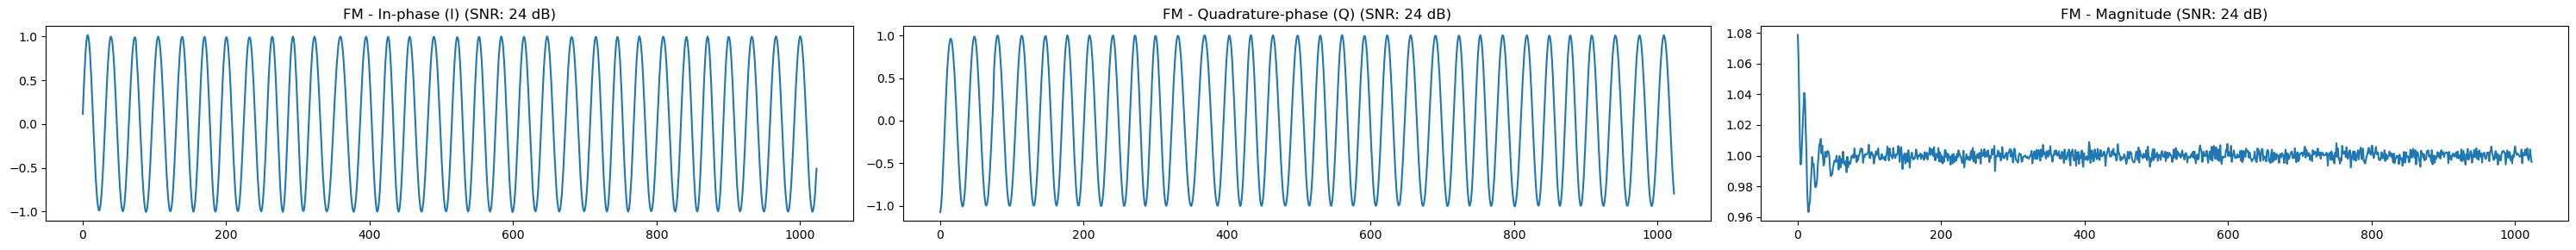

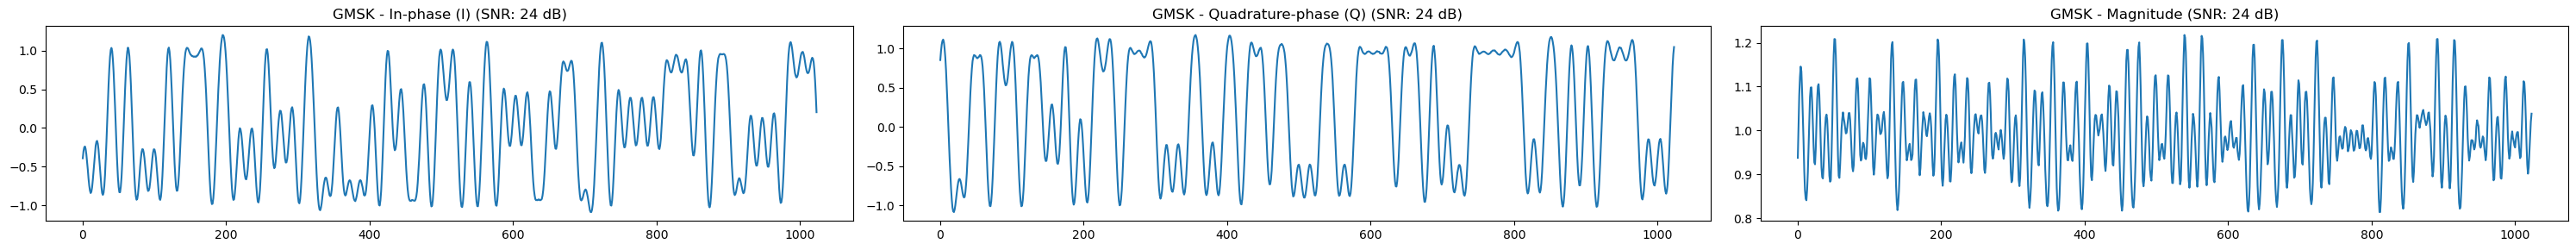

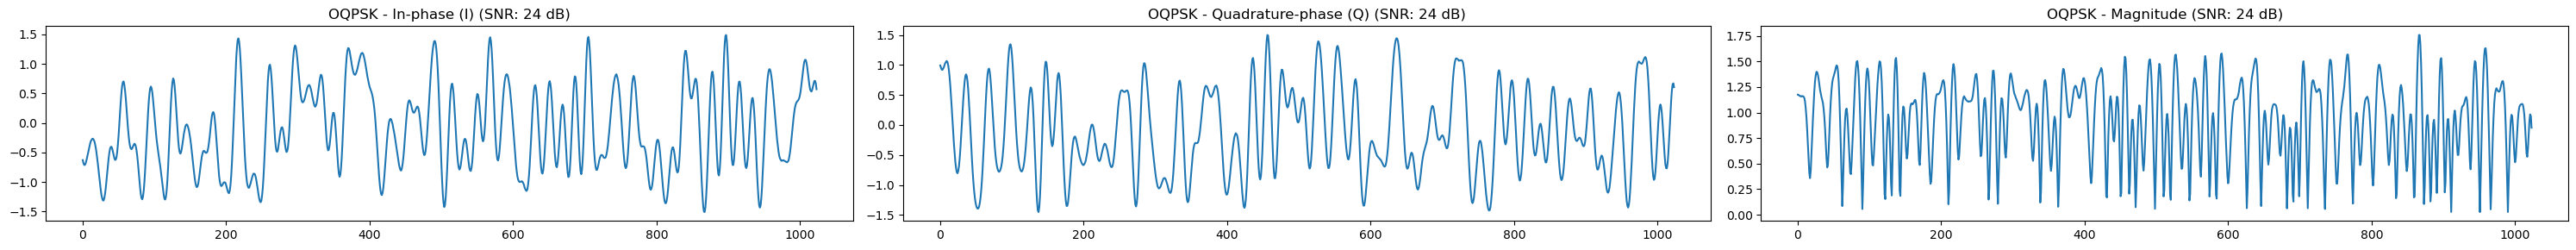

In [47]:
#Modulations-['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', 
#              '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']
"""modulation_type = '4ASK'  
snr_value = 20  
num_samples_to_plot = 2 """ 
#plot_signals_by_modulation_snr(modulation_type, snr_value, num_samples_to_plot)


plot_signals_by_modulation_snr('4ASK', 24, 1)
plot_signals_by_modulation_snr('128APSK', 24, 1)
plot_signals_by_modulation_snr('16QAM', 24, 1)
plot_signals_by_modulation_snr('256QAM', 24, 1)
plot_signals_by_modulation_snr('AM-SSB-SC', 24, 1)
plot_signals_by_modulation_snr('FM', 24, 1)
plot_signals_by_modulation_snr('GMSK', 24, 1)
plot_signals_by_modulation_snr('OQPSK', 24, 1)

In [ ]:
# tinyvgg model 
model = Sequential([
    Input(shape=(1024, 2)),
    Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation=relu),
    Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation=relu),
    MaxPool2D((2, 2)),
    Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation=relu),
    Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation=relu),
    MaxPool2D((2, 2)),
    Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation=relu),
    Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation=relu),
    MaxPool2D((2, 2)),
    Flatten(),
    Dense(24, activation=softmax),
])

count
106496    24
Name: count, dtype: int64

In [ ]:
# Create TensorFlow Dataset for X and Y data
batch_size = 128
shuffle_buffer = 10000

# Flatten the data if needed and ensure correct shape
X_data = data_array_X.reshape(-1) if len(data_array_X.shape) > 1 else data_array_X
Y_data = data_array_Y.reshape(-1) if len(data_array_Y.shape) > 1 else data_array_Y

# Convert to float32 for better performance
X_data = X_data.astype(np.float32)
Y_data = Y_data.astype(np.float32)

# Create tf.data.Dataset from tensors
dataset = tf.data.Dataset.from_tensor_slices({
    'X': X_data,
    'Y': Y_data
})

# Shuffle and batch the dataset
dataset = dataset.shuffle(buffer_size=shuffle_buffer)
dataset = dataset.batch(batch_size)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

print(f'Dataset created successfully!')
print(f'Total samples: {len(X_data)}')
print(f'Batch size: {batch_size}')
print(f'Number of batches: {len(dataset)}')
print(f'\nDataset element spec:')
print(dataset.element_spec)

# Inspect a batch
for batch in dataset.take(1):
    print(f'\nSample batch shapes:')
    print(f'  X shape: {batch["X"].shape}')
    print(f'  Y shape: {batch["Y"].shape}')


In [ ]:
# Create TensorFlow Dataset for X and Y data
batch_size = 128
shuffle_buffer = 10000

# Flatten the data if needed and ensure correct shape
X_data = data_array_X.reshape(-1) if len(data_array_X.shape) > 1 else data_array_X
Y_data = data_array_Y.reshape(-1) if len(data_array_Y.shape) > 1 else data_array_Y

# Convert to float32 for better performance
X_data = X_data.astype(np.float32)
Y_data = Y_data.astype(np.float32)

# Create tf.data.Dataset from tensors
dataset = tf.data.Dataset.from_tensor_slices({
    'X': X_data,
    'Y': Y_data
})

# Shuffle and batch the dataset
dataset = dataset.shuffle(buffer_size=shuffle_buffer)
dataset = dataset.batch(batch_size)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

print(f'Dataset created successfully!')
print(f'Total samples: {len(X_data)}')
print(f'Batch size: {batch_size}')
print(f'Number of batches: {len(dataset)}')
print(f'\nDataset element spec:')
print(dataset.element_spec)

# Inspect a batch
for batch in dataset.take(1):
    print(f'\nSample batch shapes:')
    print(f'  X shape: {batch["X"].shape}')
    print(f'  Y shape: {batch["Y"].shape}')
